# Deriving PSI3/5 values from splicing scores

This notebook demonstrates how to derive Percentage Spliced In (PSI) values from predicted splice junction counts.

PSI_5 typically refers to the usage of a 5' splice site (donor) relative to alternative donors, while PSI_3 refers to the usage of a 3' splice site (acceptor).


## Imports

In [ ]:
# @markdown Run this cell to install AlphaGenome.
from IPython.display import clear_output

! pip install alphagenome
clear_output()

In [ ]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd

## Load the model

In [ ]:
dna_model = dna_client.create(colab_utils.get_api_key())

## Score a variant

Score a variant near a known splice site:

In [ ]:
# Define a variant near a splice site in the BRCA2 gene.
variant = genome.Variant(
    chromosome='chr22',
    position=36201698,
    reference_bases='A',
    alternate_bases='C',
)

# Create a 1MB interval centered on the variant.
interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

# Predict junction counts for both REF and ALT alleles
output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.SPLICE_JUNCTIONS],
    ontology_terms=['CL:0000084'],
)

There are 107 unique junctions predicted across 2 tracks in this tissue:

In [ ]:
print(f"Junctions shape: {output.reference.splice_junctions.junctions.shape}")
print(f"Value shape: {output.reference.splice_junctions.values.shape}")

Junctions shape: (107,)
Value shape: (107, 2)


There are two tracks because splice junction counts are predicted from RNA-seq data, and there are two types of RNA-seq data available for 'CL:0000084':

*   polyA RNA-seq for mature mRNA splicing because it enriches for fully processed transcripts.
*   Total RNA-seq captures pre-mRNA and nascent transcripts, which can sometimes look "messier" because splicing is still in progress.

In [ ]:
output.reference.splice_junctions.metadata

,name,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,Assay title
0,junction_CL:0000084 polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,polyA plus RNA-seq
1,junction_CL:0000084 total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,total RNA-seq


## Derive the PSI values

Create a function to calculate PSI values from splice junction counts for either RNA track:

In [ ]:
def compute_psi_from_raw(junction_data, track_idx):
  # Create the dataframe from known attributes
  data = []
  for i, j in enumerate(junction_data.junctions):
    # Determine Donor and Acceptor based on strand
    if j.strand == '+':
      donor, acceptor = j.start, j.end
    else:
      donor, acceptor = j.end, j.start

    data.append({
        'donor': donor,
        'acceptor': acceptor,
        'count': junction_data.values[i, track_idx],
    })

  df = pd.DataFrame(data)

  # Pivot into the matrix: Rows = Donors, Cols = Acceptors
  matrix = df.pivot_table(
      index='donor', columns='acceptor', values='count', fill_value=0
  )

  # PSI5: Normalize row-wise (Percent of donor usage for each acceptor)
  # PSI5 = Count / (Total counts for that Donor)
  psi5 = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

  # PSI3: Normalize column-wise (Percent of acceptor usage for each donor)
  # PSI3 = Count / (Total counts for that Acceptor)
  psi3 = matrix.div(matrix.sum(axis=0), axis=1).fillna(0)

  return psi5, psi3

Select RNA track and calculate:

In [ ]:
# We can use either RNA track for PSI values
titles = (
    output.reference.splice_junctions.metadata['Assay title']
    .astype(str)
    .tolist()
)
polya_idx = next(
    (i for i, t in enumerate(titles) if 'polya' in t.lower()), None
)
total_idx = next(
    (i for i, t in enumerate(titles) if 'total' in t.lower()), None
)

# Indecies
print(f'Indices found -> PolyA: {polya_idx}, Total: {total_idx}')

# Calululate PSI
psi5_total, psi3_total = compute_psi_from_raw(
    output.reference.splice_junctions, polya_idx
)

## Inspect results

In [ ]:
print(
    'The proportion of total splicing activity at a specific acceptor site that'
    ' is contributed by a given donor'
)
display(psi3_total.head())

print(
    'The proportion of total splicing activity at a specific donor site that is'
    ' directed to a given acceptor'
)
display(psi5_total.head())

The proportion of total splicing activity at a specific acceptor site that is contributed by a given donor


acceptor,36191912,36195432,36195437,36197831,36198896,36199369,36199376,36199608,36200291,36201796,36201851,36201888,36202055,36202094,36202933
donor,,,,,,,,,,,,,,,
36192925,0.018779,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195094,0.016944,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195310,0.908919,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195912,0.004811,0.093950,0.016829,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36197944,0.005078,0.087348,0.017657,0.100797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The proportion of total splicing activity at a specific donor site that is directed to a given acceptor


acceptor,36191912,36195432,36195437,36197831,36198896,36199369,36199376,36199608,36200291,36201796,36201851,36201888,36202055,36202094,36202933
donor,,,,,,,,,,,,,,,
36192925,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195094,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195310,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195912,0.153461,0.215491,0.631047,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36197944,0.129979,0.160791,0.531372,0.177858,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Visualise Sashimi plot

As we are considering splicing, we may want to plot more than just protein coding and MANE transcripts. Choose a relevant extractor, but be aware that including all possible transcripts can result in a crowded annotation:

In [ ]:
# The GTF file contains information on the location of all transcripts.
# Note that we use genome assembly hg38 for human.
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# All transcripts
transcript_extractor_all = transcript_utils.TranscriptExtractor(gtf)

# All protein-coding transcripts
gtf_protein = gene_annotation.filter_protein_coding(gtf)
transcript_extractor_protein = transcript_utils.TranscriptExtractor(gtf_protein)

# All MANE transcripts
gtf_mane = gene_annotation.filter_to_mane_select_transcript(gtf)
transcript_extractor_mane = transcript_utils.TranscriptExtractor(gtf_mane)

# All MANE protein-coding transcripts
gtf_mane_protein = gene_annotation.filter_protein_coding(gtf)
gtf_mane_protein = gene_annotation.filter_to_mane_select_transcript(
    gtf_mane_protein
)
transcript_extractor_mane_protein = transcript_utils.TranscriptExtractor(
    gtf_mane_protein
)

Build the Sashimi plot. The numbers above the junctions in the Sashimi plot are the predicted normalised read counts per donor/acceptor pair (quantitative signal strength). These are NOT the PSI values (proportions):

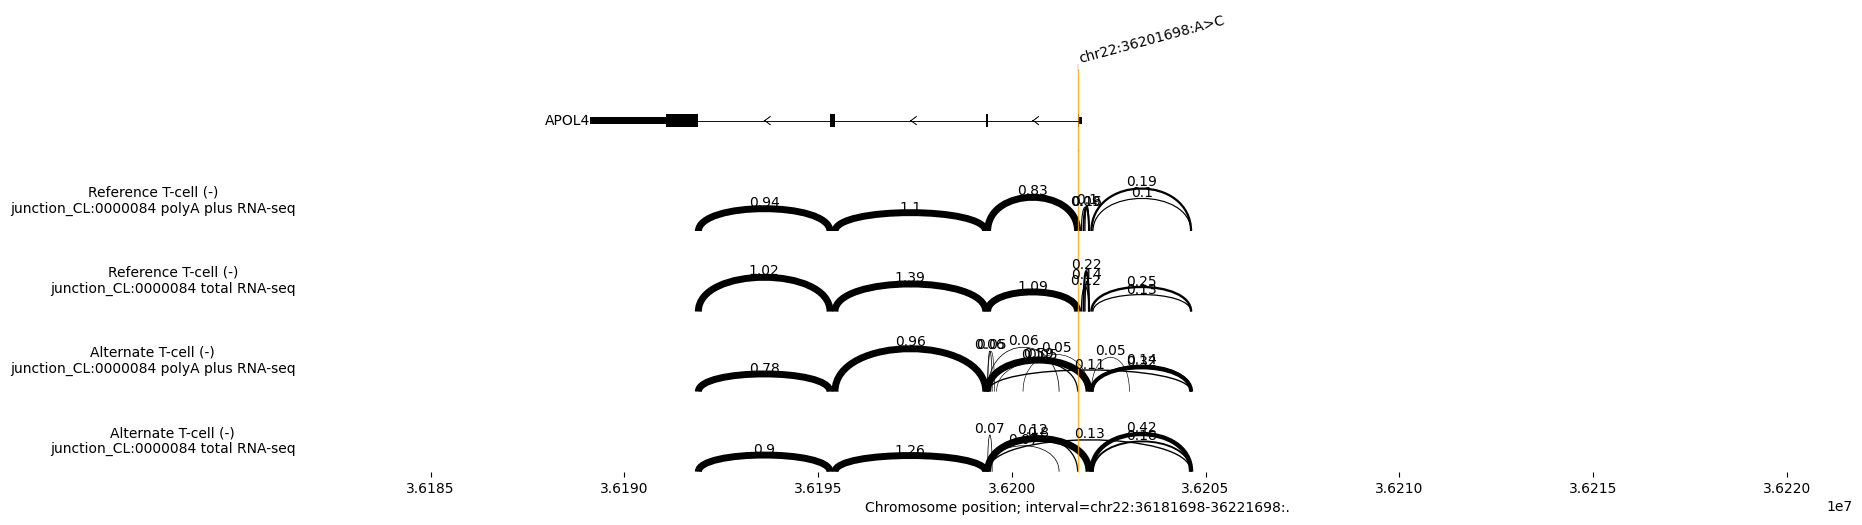

In [ ]:
# We will plot for both polyA and total RNA-seq
ref_output = output.reference
alt_output = output.alternate

# Plot
_ = plot_components.plot(
    [
        # Transcript annotations
        plot_components.TranscriptAnnotation(
            transcript_extractor_mane.extract(interval)
        ),
        # Sashimi ref and alt plots
        plot_components.Sashimi(
            ref_output.splice_junctions,
            ylabel_template='Reference {biosample_name} ({strand})\n{name}',
            color='skyblue',
        ),
        plot_components.Sashimi(
            alt_output.splice_junctions,
            ylabel_template='Alternate {biosample_name} ({strand})\n{name}',
            color='red',
        ),
    ],
    # Annotate the variant position as a vertical line across all panels
    annotations=[plot_components.VariantAnnotation([variant])],
    interval=interval.resize(40000),
)

plt.show()
